# Bước 03 — DDPM sampling (sinh ảnh từ nhiễu)

Notebook giải thích từng phần của [`03_sample_ddpm.py`](./03_sample_ddpm.py).

**Mục tiêu:** Hiểu *reverse process* — dùng UNet đã train (bước 02) để đi **ngược** forward: nhiễu thuần → ảnh MNIST.

| Khái niệm | Ý nghĩa nhanh |
|-----------|----------------|
| `x_T` | Nhiễu Gaussian thuần (điểm bắt đầu sampling) |
| `p_sample` | Một bước denoise: `x_t → x_{t-1}` |
| DDPM sampling | Lặp `T=1000` bước `p_sample` |
| Train vs sample | Train: random `t`, học predict noise · Sample: `t` giảm dần 999→0 |

**Điều kiện:** cần checkpoint `assets/ddpm_mnist.pt` (chạy [`02_train_ddpm.py`](./02_train_ddpm.py) hoặc notebook bước 02 trước).

**Chạy notebook:** kernel Python 3.10+ · chạy **tuần tự từ trên xuống**.

> **Thời gian:** DDPM = **1000 bước** UNet/ảnh — mặc định `N_SAMPLES=16` (~ vài phút MPS). Script gốc sinh 64 ảnh.

> Liên hệ SwiftEdit: pipeline edit cũng **denoise** từ latent/noise; SwiftEdit rút gọn **inversion** (ảnh→noise) còn 1 bước — sampling/edit vẫn dựa trên UNet tương tự.

## 0. Setup — đường dẫn & import

Notebook phải chạy từ thư mục `learn/diffusion-from-scratch/`.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "diffusion" / "schedule.py").exists():
    raise FileNotFoundError(
        f"Không thấy diffusion/schedule.py trong {ROOT}.\n"
        "Mở notebook từ thư mục learn/diffusion-from-scratch/ hoặc cd vào đó trước."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from diffusion import LinearSchedule, UNet
from diffusion.utils import set_seed, get_device, plot_grid

set_seed(42)
device = get_device()
assets_dir = ROOT / "assets"
assets_dir.mkdir(exist_ok=True)
CHECKPOINT = assets_dir / "ddpm_mnist.pt"

print("ROOT:", ROOT)
print("PyTorch:", torch.__version__)
print("Device:", device)
print("Checkpoint:", CHECKPOINT, "→", "OK" if CHECKPOINT.exists() else "THIẾU — chạy bước 02 trước")

ROOT: /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch
PyTorch: 2.12.0
Device: mps
Checkpoint: /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/ddpm_mnist.pt → OK


## 1. Forward vs reverse — train đã học gì, sample làm gì?

| | Bước 01–02 (train) | Bước 03 (sample) |
|--|-------------------|------------------|
| Hướng | `x_0` → `x_t` (thêm nhiễu) | `x_T` → `x_0` (bớt nhiễu) |
| Input UNet | `x_t` noised + `t` | `x_t` noised + `t` (giảm dần) |
| Output UNet | `epsilon_pred` ≈ noise thật | Cùng output — dùng trong công thức `p_sample` |
| `t` | Random mỗi batch | Tuần tự `999, 998, …, 0` |

**Ý tưởng sampling:**

1. Bắt đầu `x ~ N(0, I)` — ảnh toàn nhiễu (`t ≈ T`)
2. Mỗi bước: UNet đoán noise → tính `x_{t-1}` hơi sạch hơn (`schedule.p_sample`)
3. Sau 1000 bước → `x_0` trông như chữ số MNIST

## 2. Load model đã train

Cùng kiến trúc UNet bước 02 — chỉ **load weights**, không train thêm. `model.eval()` khi sampling.

In [2]:
if not CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Không thấy {CHECKPOINT}.\n"
        "Chạy: python 02_train_ddpm.py  hoặc notebook 02_train_ddpm.ipynb (mục 5)."
    )

T = 1000
schedule = LinearSchedule(T=T, device=device)
model = UNet(in_ch=1, base_ch=32, time_dim=128).to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device, weights_only=True))
model.eval()

print(f"Đã load UNet từ {CHECKPOINT.name}")
print(f"Schedule T = {schedule.T}")

Đã load UNet từ ddpm_mnist.pt
Schedule T = 1000


## 3. Một bước `p_sample` — `x_t → x_{t-1}`

Trong `diffusion/schedule.py`, `p_sample`:

1. `eps_pred = model(x_t, t)`
2. Tính **mean** của phân phối `p(x_{t-1} | x_t)` (công thức DDPM paper)
3. Nếu `t > 0`: cộng thêm noise nhỏ (stochastic) · `t = 0`: trả mean (ảnh cuối)

Cell dưới chạy **một bước** từ nhiễu ngẫu nhiên tại `t=999`.

t = 999, alpha_bar = 0.0000
x_t std ~ 1.00 (gần nhiễu)
x_{t-1} std ~ 1.00


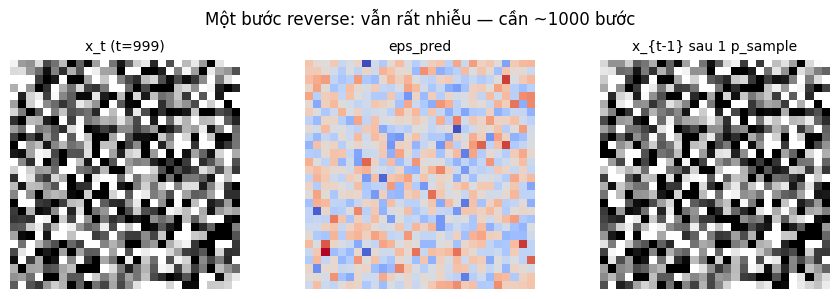

In [3]:
t_demo = 999
x_t = torch.randn(1, 1, 28, 28, device=device)

with torch.no_grad():
    eps_pred = model(x_t, torch.tensor([t_demo], device=device))
    x_prev = schedule.p_sample(model, x_t, t_demo)

print(f"t = {t_demo}, alpha_bar = {schedule.alpha_bar[t_demo]:.4f}")
print(f"x_t std ~ {x_t.std():.2f} (gần nhiễu)")
print(f"x_{{t-1}} std ~ {x_prev.std():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, tensor, title in zip(
    axes,
    [x_t, eps_pred, x_prev],
    [f"x_t (t={t_demo})", "eps_pred", f"x_{{t-1}} sau 1 p_sample"],
):
    img = tensor.squeeze().cpu().numpy()
    if title.startswith("eps"):
        ax.imshow(img, cmap="coolwarm")
    else:
        ax.imshow((img + 1) / 2, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.suptitle("Một bước reverse: vẫn rất nhiễu — cần ~1000 bước", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Hàm `sample_ddpm` — giống script gốc

Lặp `t` từ `T-1` về `0`, mỗi lần gọi `p_sample`. Không tính gradient (`@torch.no_grad()`).

In [4]:
@torch.no_grad()
def sample_ddpm(model, schedule, n_samples=16, device="cpu", show_progress=True):
    """Full DDPM sampling: T denoising steps (giống 03_sample_ddpm.py)."""
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    timesteps = range(schedule.T - 1, -1, -1)
    if show_progress:
        timesteps = tqdm(timesteps, desc="DDPM sampling")

    for t in timesteps:
        x = schedule.p_sample(model, x, t)

    return (x.clamp(-1, 1) + 1) / 2  # scale về [0, 1] để hiển thị

## 5. Sinh batch ảnh MNIST

Script gốc: `n_samples=64`. Notebook mặc định **16** cho nhanh — đổi `N_SAMPLES = 64` nếu muốn giống README.

Sinh 30 ảnh — DDPM 1000 bước/ảnh...


DDPM sampling: 100%|██████████| 1000/1000 [00:19<00:00, 50.50it/s]


Shape: (30, 1, 28, 28) — (batch, channel, H, W), pixel [0,1]
Đã lưu → /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/ddpm_samples_notebook.png


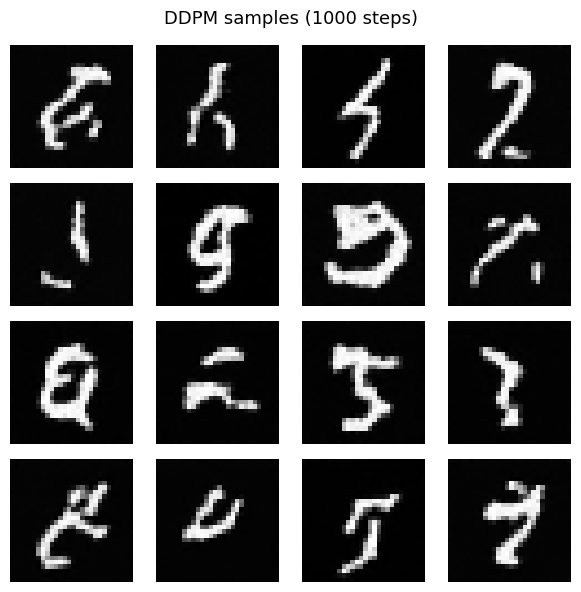

In [7]:
N_SAMPLES = 30  # script gốc: 64

print(f"Sinh {N_SAMPLES} ảnh — DDPM {T} bước/ảnh...")
samples = sample_ddpm(model, schedule, n_samples=N_SAMPLES, device=device)
print("Shape:", tuple(samples.shape), "— (batch, channel, H, W), pixel [0,1]")

nrow = 4
fig, axes = plt.subplots(nrow, nrow, figsize=(6, 6))
fig.suptitle(f"DDPM samples ({T} steps)", fontsize=13)
for ax, img in zip(axes.flat, samples):
    ax.imshow(img.squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
for ax in axes.flat[len(samples):]:
    ax.axis("off")
fig.tight_layout()

out_path = assets_dir / "ddpm_samples_notebook.png"
fig.savefig(out_path, dpi=150)
print(f"Đã lưu → {out_path}")
plt.show()

## 6. Tiến trình denoise — `x_T → x_0` (một ảnh)

Giống phần cuối `03_sample_ddpm.py`: lưu snapshot tại các `t` để thấy ảnh **dần hiện ra**.

> Chạy 1000 bước — mất vài phút. Có progress bar.

Denoising 1 ảnh: 100%|██████████| 1000/1000 [00:06<00:00, 149.04it/s]


Selected x_0 = torch.Size([1, 1, 28, 28])
Đã lưu → /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/denoising_steps_notebook.png


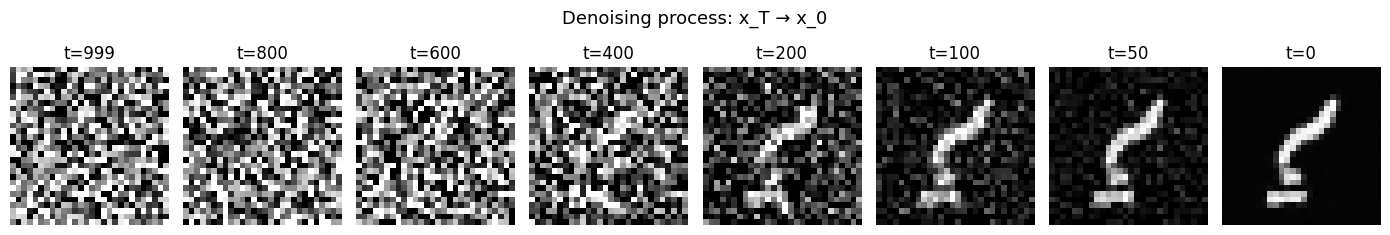

In [13]:
save_at = [999, 800, 600, 400, 200, 100, 50, 0]
x = torch.randn(1, 1, 28, 28, device=device)
snapshots = []

model.eval()
shape = x.shape
with torch.no_grad():
    for t in tqdm(range(999, -1, -1), desc="Denoising 1 ảnh"):
        x = schedule.p_sample(model, x, t)
        if t in save_at:
            snapshots.append(((x.clamp(-1, 1) + 1) / 2, t))

fig, axes = plt.subplots(1, len(snapshots), figsize=(14, 2.5))
fig.suptitle("Denoising process: x_T → x_0", fontsize=13)
print("Selected x_0 =", shape)

for ax, (snap, t) in zip(axes, snapshots):
    ax.imshow(snap[0, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"t={t}")
    ax.axis("off")
fig.tight_layout()

out_path = assets_dir / "denoising_steps_notebook.png"
fig.savefig(out_path, dpi=150)
print(f"Đã lưu → {out_path}")
plt.show()

## 7. Tóm tắt & bước tiếp theo

### Bạn vừa học được

1. **Sampling** = reverse process: nhiễu → 1000× `p_sample` → ảnh.
2. UNet train ở bước 02 **tái sử dụng nguyên** — không train lại khi sample.
3. DDPM sampling **chậm** vì mỗi ảnh = 1000 forward pass UNet.

### Bước tiếp theo

| File | Nội dung |
|------|----------|
| [`04_sample_ddim.py`](./04_sample_ddim.py) | Cùng weights, chỉ ~50 bước (DDIM) |

### SwiftEdit (CS2309)

- Sinh/chỉnh ảnh SD cũng là chuỗi denoise trong latent — nhưng ít bước hơn (DDIM, distilled).
- **Inversion** (ảnh thật → noise) là reverse của forward — method cũ multi-step; SwiftEdit = `F_theta` one-step.

**Checklist hiểu bài (tự kiểm):**

- [ ] Phân biệt train (random `t`, học noise) vs sample (`t` 999→0)
- [ ] Giải thích `p_sample` làm gì trong một bước
- [ ] Biết vì sao DDPM chậm (1000 UNet calls/ảnh)

→ Tiếp: `04_sample_ddim.py` / notebook bước 04.